In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [2]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

#data = data[data['LOGG'] > 1.4]

In [3]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

In [4]:
from chemevo import evolution_V1 as evo

mg_h_big_bin_edges = np.arange(-0.8, 0.4, 0.2) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

data['MG_H_big_bin'] = pd.cut(data['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)

xs = np.linspace(-1, 1, 100)

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
t_array_trunc = np.linspace(0.0001,6,int(1e3))
dt = t_array[1] - t_array[0]

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

etas = [0, 0.5, 1]
tau_stars = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]
colors_lines = ['blue', 'orange', 'green', 'red', 'purple', 'teal', 'magenta', 'brown', 'navy', 'maroon']
colors_dots = ['greenyellow', 'cyan', 'orange', 'blue', 'red', 'yellow', 'green', 'gray', 'peru', 'navy']


gals_taustar_eta0 = []

for i in range(len(tau_stars)):
    gals_taustar_eta0.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0]))

g_cc_Fe = 4.73/13.7
g_Mn_ratio = 1.5
g_cc_Mns = [0.75 * g_cc_Fe, g_cc_Fe, g_cc_Fe * 1.5, g_cc_Fe * 2, g_cc_Fe * 3]

gals_gcc_0 = []
gals_gcc_1 = []
gals_gcc_2 = []
gals_gcc_3 = []
gals_gcc_4 = []

for i in range(len(tau_stars)):
    gals_gcc_0.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], g_cc_Mn=g_cc_Mns[0]))

for i in range(len(tau_stars)):
    gals_gcc_1.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], g_cc_Mn=g_cc_Mns[1]))

for i in range(len(tau_stars)):
    gals_gcc_2.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], g_cc_Mn=g_cc_Mns[2]))

for i in range(len(tau_stars)):
    gals_gcc_3.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], g_cc_Mn=g_cc_Mns[3]))

for i in range(len(tau_stars)):
    gals_gcc_4.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], g_cc_Mn=g_cc_Mns[4]))


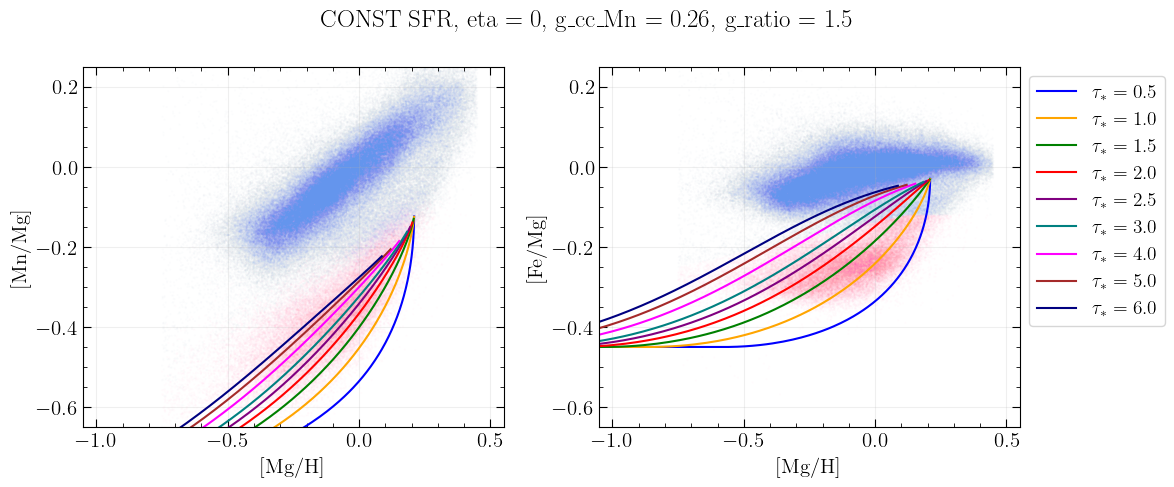

In [5]:
fig = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = data['color'], s = 0.5)


for i in range(len(gals_gcc_0)):
    gal = gals_gcc_0[i]
    plt.plot(gal.Mg_H, gal.Mn_Mg, color = colors_lines[i], linestyle='-')


plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.01, color = data['color'], s = 0.5)

for i in range(len(gals_gcc_0)):
    gal = gals_gcc_0[i]
    plt.plot(gal.Mg_H[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.xlim(65,0.25)
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

plt.legend(bbox_to_anchor=[1, 1])

plt.suptitle(rf"CONST SFR, eta = 0, g_cc_Mn = {g_cc_Mns[0]:.2f}, g_ratio = 1.5")
plt.tight_layout()

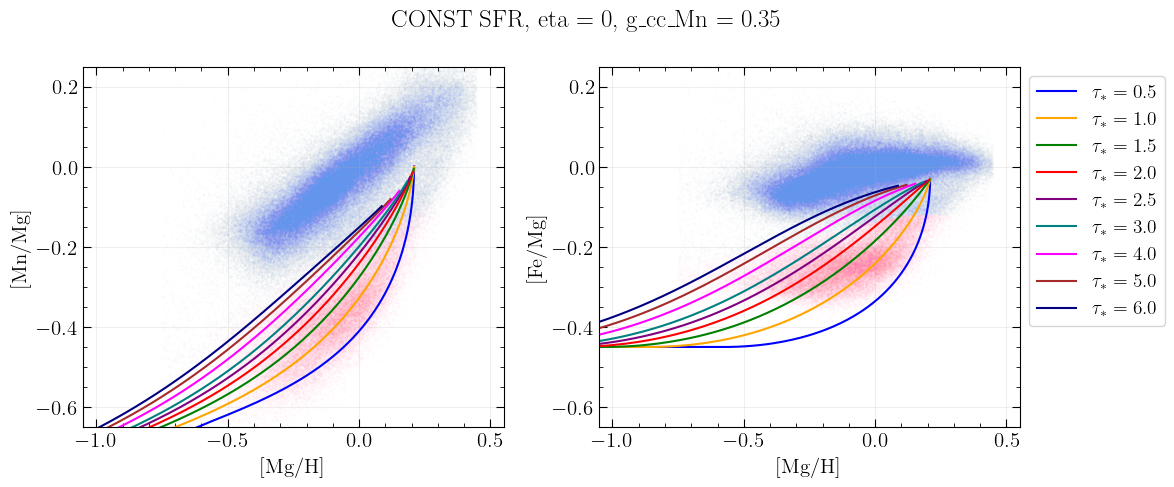

In [6]:
fig = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = data['color'], s = 0.5)


for i in range(len(gals_gcc_1)):
    gal = gals_gcc_1[i]
    plt.plot(gal.Mg_H, gal.Mn_Mg, color = colors_lines[i], linestyle='-')


plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.01, color = data['color'], s = 0.5)

for i in range(len(gals_gcc_1)):
    gal = gals_gcc_1[i]
    plt.plot(gal.Mg_H[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.xlim(65,0.25)
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

plt.legend(bbox_to_anchor=[1, 1])

plt.suptitle(rf"CONST SFR, eta = 0, g_cc_Mn = {g_cc_Mns[1]:.2f}")
plt.tight_layout()

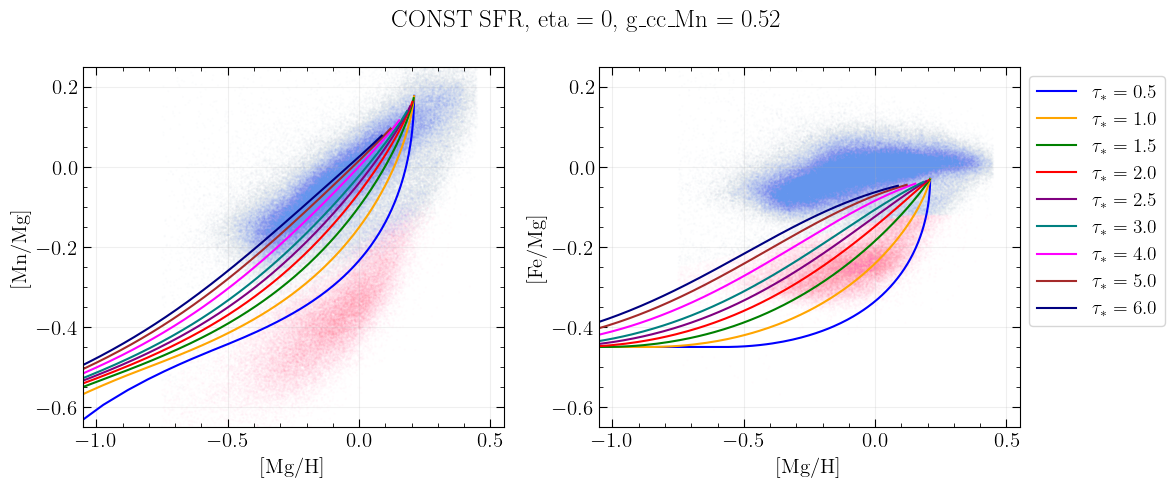

In [7]:
fig = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = data['color'], s = 0.5)


for i in range(len(gals_gcc_2)):
    gal = gals_gcc_2[i]
    plt.plot(gal.Mg_H, gal.Mn_Mg, color = colors_lines[i], linestyle='-')


plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.01, color = data['color'], s = 0.5)

for i in range(len(gals_gcc_2)):
    gal = gals_gcc_2[i]
    plt.plot(gal.Mg_H[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.xlim(65,0.25)
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

plt.legend(bbox_to_anchor=[1, 1])

plt.suptitle(rf"CONST SFR, eta = 0, g_cc_Mn = {g_cc_Mns[2]:.2f}")
plt.tight_layout()

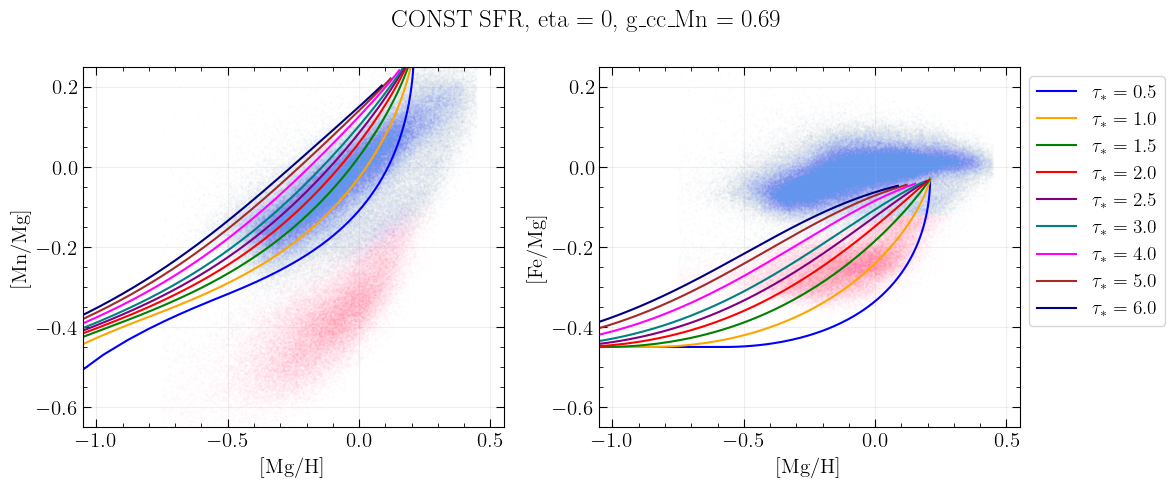

In [8]:
fig = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = data['color'], s = 0.5)


for i in range(len(gals_gcc_3)):
    gal = gals_gcc_3[i]
    plt.plot(gal.Mg_H, gal.Mn_Mg, color = colors_lines[i], linestyle='-')


plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.01, color = data['color'], s = 0.5)

for i in range(len(gals_gcc_3)):
    gal = gals_gcc_3[i]
    plt.plot(gal.Mg_H[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.xlim(65,0.25)
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

plt.legend(bbox_to_anchor=[1, 1])

plt.suptitle(rf"CONST SFR, eta = 0, g_cc_Mn = {g_cc_Mns[3]:.2f}")
plt.tight_layout()

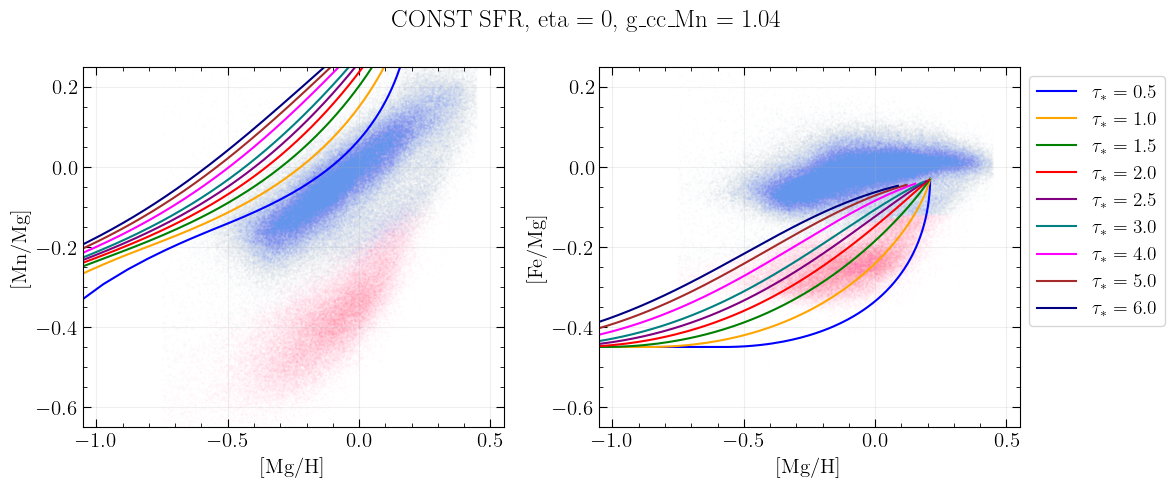

In [9]:
fig = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = data['color'], s = 0.5)


for i in range(len(gals_gcc_4)):
    gal = gals_gcc_4[i]
    plt.plot(gal.Mg_H, gal.Mn_Mg, color = colors_lines[i], linestyle='-')


plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.01, color = data['color'], s = 0.5)

for i in range(len(gals_gcc_4)):
    gal = gals_gcc_4[i]
    plt.plot(gal.Mg_H[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.xlim(65,0.25)
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

plt.legend(bbox_to_anchor=[1, 1])

plt.suptitle(rf"CONST SFR, eta = 0, g_cc_Mn = {g_cc_Mns[4]:.2f}")
plt.tight_layout()

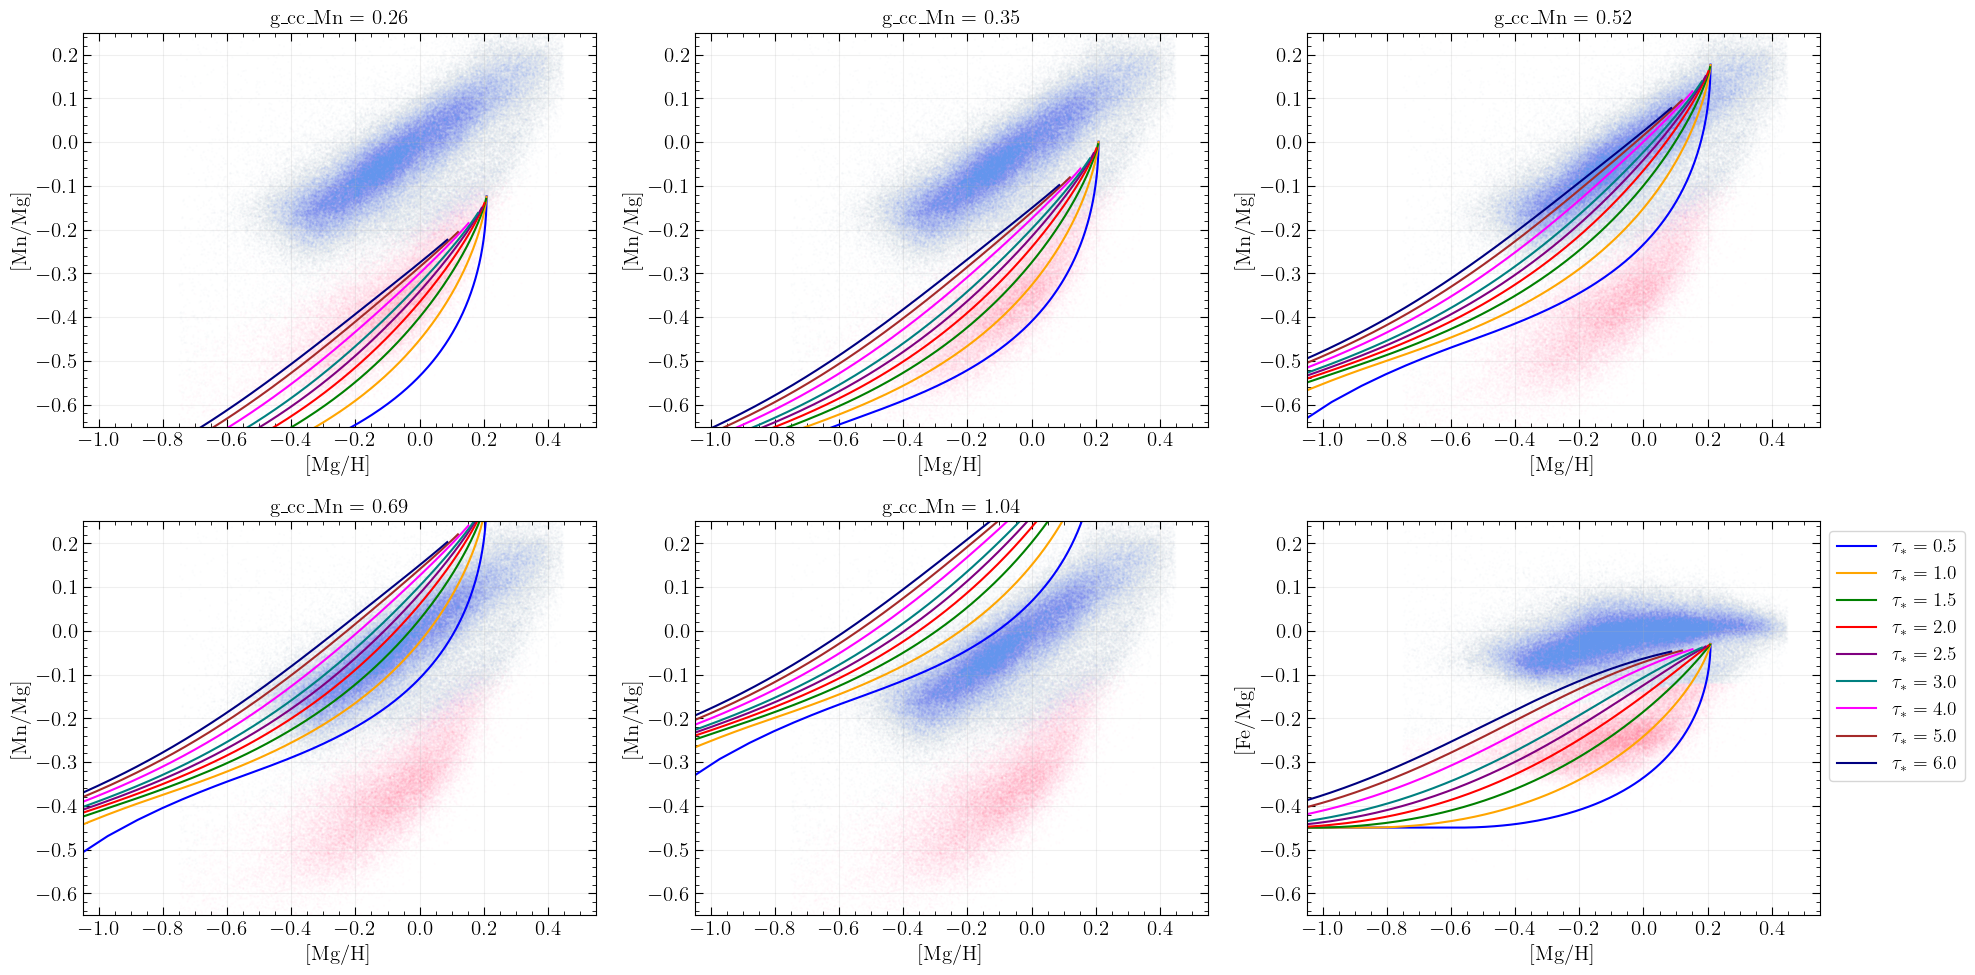

In [10]:
plt.figure(figsize=(20,10))

plt.subplot(2, 3, 1)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = data['color'], s = 0.5)
for i in range(len(gals_gcc_0)):
    gal = gals_gcc_0[i]
    plt.plot(gal.Mg_H, gal.Mn_Mg, color = colors_lines[i], linestyle='-')
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)
plt.title((rf"g_cc_Mn = {g_cc_Mns[0]:.2f}"))

plt.subplot(2, 3, 2)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = data['color'], s = 0.5)
for i in range(len(gals_gcc_1)):
    gal = gals_gcc_1[i]
    plt.plot(gal.Mg_H, gal.Mn_Mg, color = colors_lines[i], linestyle='-')
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)
plt.title((rf"g_cc_Mn = {g_cc_Mns[1]:.2f}"))

plt.subplot(2, 3, 3)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = data['color'], s = 0.5)
for i in range(len(gals_gcc_2)):
    gal = gals_gcc_2[i]
    plt.plot(gal.Mg_H, gal.Mn_Mg, color = colors_lines[i], linestyle='-')
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)
plt.title((rf"g_cc_Mn = {g_cc_Mns[2]:.2f}"))

plt.subplot(2, 3, 4)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = data['color'], s = 0.5)
for i in range(len(gals_gcc_3)):
    gal = gals_gcc_3[i]
    plt.plot(gal.Mg_H, gal.Mn_Mg, color = colors_lines[i], linestyle='-')
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)
plt.title((rf"g_cc_Mn = {g_cc_Mns[3]:.2f}"))

plt.subplot(2, 3, 5)
plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = data['color'], s = 0.5)
for i in range(len(gals_gcc_4)):
    gal = gals_gcc_4[i]
    plt.plot(gal.Mg_H, gal.Mn_Mg, color = colors_lines[i], linestyle='-')
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)
plt.title((rf"g_cc_Mn = {g_cc_Mns[4]:.2f}"))


plt.subplot(2,3,6)
plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.01, color = data['color'], s = 0.5)
for i in range(len(gals_gcc_0)):
    gal = gals_gcc_0[i]
    plt.plot(gal.Mg_H[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.xlim(65,0.25)
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.legend(bbox_to_anchor=[1, 1])

plt.tight_layout()

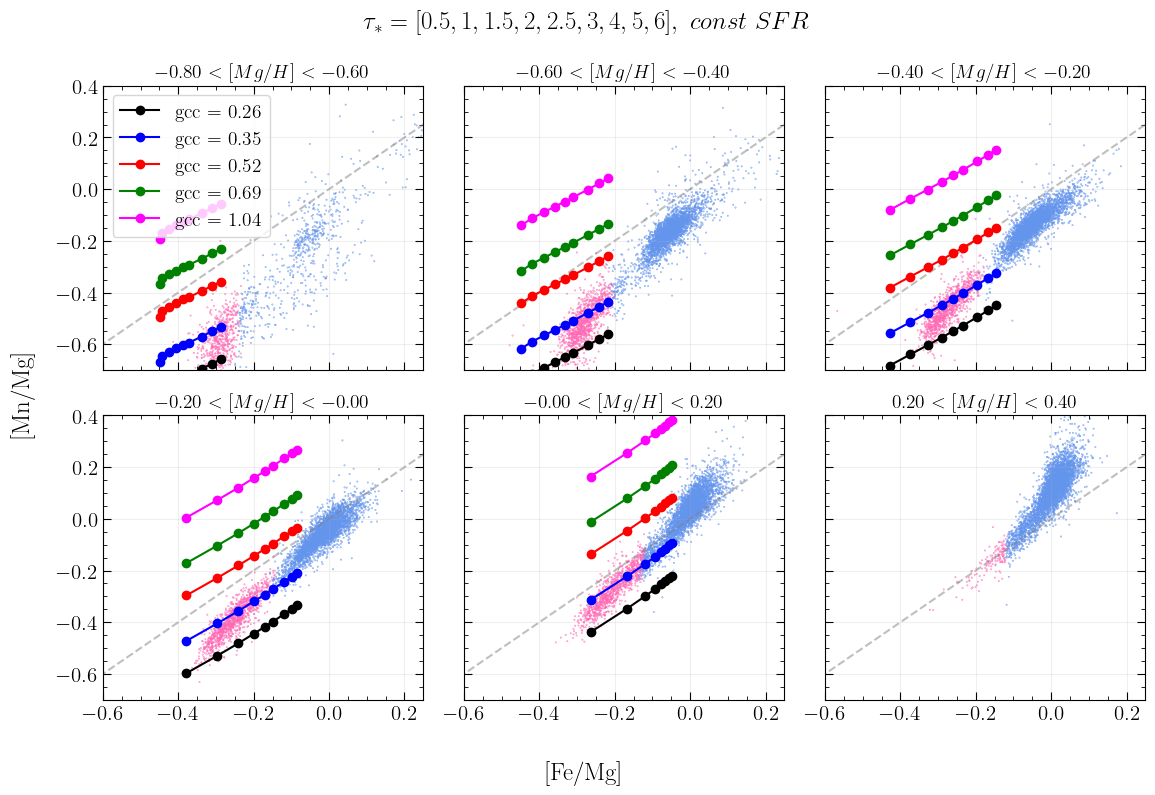

In [11]:
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []

    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            mg_h = gal.Mg_H
            for indx in range(len(mg_h)):
                mg_h_at_time = mg_h[indx]
                if mg_h_at_time > bin_cent:
                    endpoints.append(indx)
                    break

        endpoints_gals.append(np.array(endpoints))

    return endpoints_gals

gals_endpoints = {
    0: find_endpoints(gals_gcc_0, mg_h_big_bin_centers),
    1: find_endpoints(gals_gcc_1, mg_h_big_bin_centers),
    2: find_endpoints(gals_gcc_2, mg_h_big_bin_centers),
    3: find_endpoints(gals_gcc_3, mg_h_big_bin_centers),
    4: find_endpoints(gals_gcc_4, mg_h_big_bin_centers)
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Background data
    df = data[data['MG_H_big_bin'] == i]
    df = downsample(df, 5000)
    ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color=df['color'])

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequence (η = 0 shown here)
    endpoints_0 = gals_endpoints[0][i]
    fe_mg_gcc0 = []
    mn_mg_gcc0 = []

    endpoints_1 = gals_endpoints[1][i]
    fe_mg_gcc1 = []
    mn_mg_gcc1 = []

    endpoints_2 = gals_endpoints[2][i]
    fe_mg_gcc2 = []
    mn_mg_gcc2 = []

    endpoints_3 = gals_endpoints[3][i]
    fe_mg_gcc3 = []
    mn_mg_gcc3 = []

    endpoints_4 = gals_endpoints[4][i]
    fe_mg_gcc4 = []
    mn_mg_gcc4 = []

    for gal, idx in zip(gals_gcc_0, endpoints_0):
        fe_mg_gcc0.append(gal.Fe_Mg[idx])
        mn_mg_gcc0.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_gcc_1, endpoints_1):
        fe_mg_gcc1.append(gal.Fe_Mg[idx])
        mn_mg_gcc1.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_gcc_2, endpoints_2):
        fe_mg_gcc2.append(gal.Fe_Mg[idx])
        mn_mg_gcc2.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_gcc_3, endpoints_3):
        fe_mg_gcc3.append(gal.Fe_Mg[idx])
        mn_mg_gcc3.append(gal.Mn_Mg[idx])
    
    for gal, idx in zip(gals_gcc_4, endpoints_4):
        fe_mg_gcc4.append(gal.Fe_Mg[idx])
        mn_mg_gcc4.append(gal.Mn_Mg[idx])


    ax.plot(fe_mg_gcc0, mn_mg_gcc0, 'o-', color='black', linewidth=1.5, label = f'gcc = {g_cc_Mns[0]:.2f}')
    ax.plot(fe_mg_gcc1, mn_mg_gcc1, 'o-', color='blue', linewidth=1.5, label = f'gcc = {g_cc_Mns[1]:.2f}')
    ax.plot(fe_mg_gcc2, mn_mg_gcc2, 'o-', color='red', linewidth=1.5, label = f'gcc = {g_cc_Mns[2]:.2f}')
    ax.plot(fe_mg_gcc3, mn_mg_gcc3, 'o-', color='green', linewidth=1.5, label = f'gcc = {g_cc_Mns[3]:.2f}')
    ax.plot(fe_mg_gcc4, mn_mg_gcc4, 'o-', color='magenta', linewidth=1.5, label = f'gcc = {g_cc_Mns[4]:.2f}')
    if i == 0:
        ax.legend()

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \ const\ SFR$")
plt.tight_layout()
plt.show()


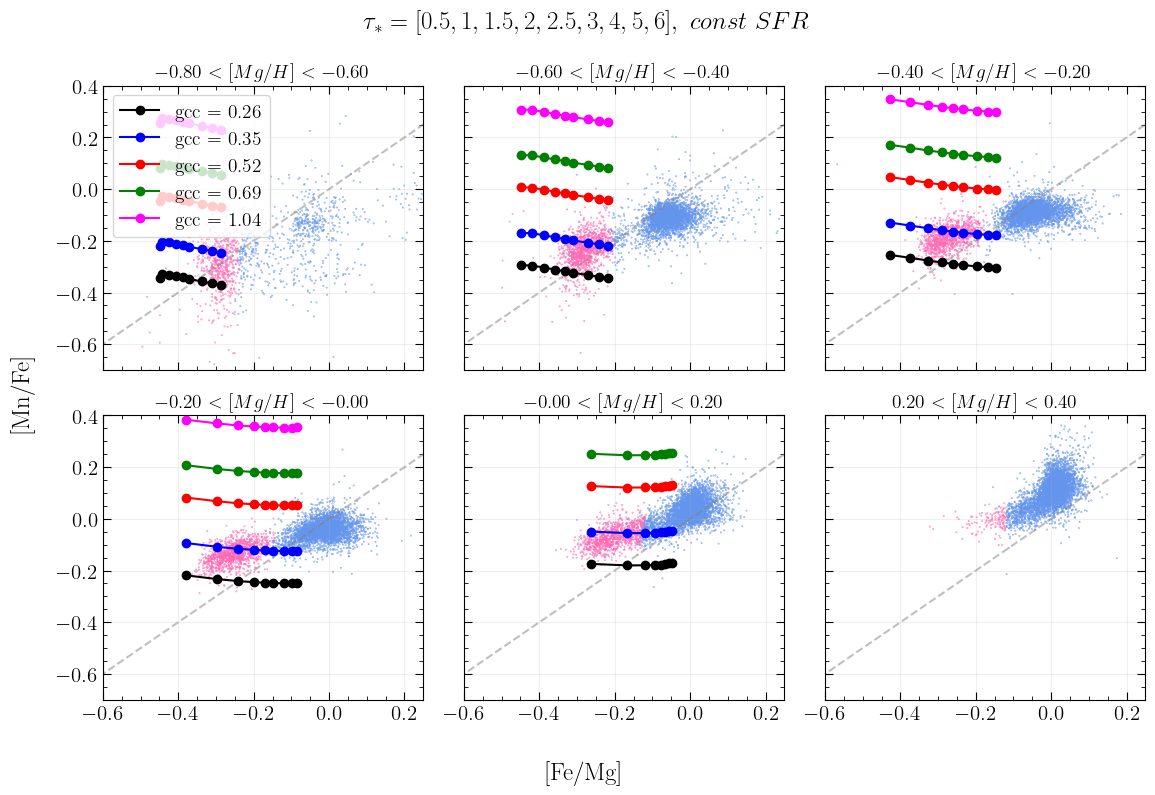

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Background data
    df = data[data['MG_H_big_bin'] == i]
    df = downsample(df, 5000)
    ax.scatter(df['FE_MG'], df['MN_FE'], s=0.1, color=df['color'])

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequence (η = 0 shown here)
    endpoints_0 = gals_endpoints[0][i]
    fe_mg_gcc0 = []
    mn_fe_gcc0 = []

    endpoints_1 = gals_endpoints[1][i]
    fe_mg_gcc1 = []
    mn_fe_gcc1 = []

    endpoints_2 = gals_endpoints[2][i]
    fe_mg_gcc2 = []
    mn_fe_gcc2 = []

    endpoints_3 = gals_endpoints[3][i]
    fe_mg_gcc3 = []
    mn_fe_gcc3 = []

    endpoints_4 = gals_endpoints[4][i]
    fe_mg_gcc4 = []
    mn_fe_gcc4 = []

    for gal, idx in zip(gals_gcc_0, endpoints_0):
        fe_mg_gcc0.append(gal.Fe_Mg[idx])
        mn_fe_gcc0.append(gal.Mn_Fe[idx])

    for gal, idx in zip(gals_gcc_1, endpoints_1):
        fe_mg_gcc1.append(gal.Fe_Mg[idx])
        mn_fe_gcc1.append(gal.Mn_Fe[idx])

    for gal, idx in zip(gals_gcc_2, endpoints_2):
        fe_mg_gcc2.append(gal.Fe_Mg[idx])
        mn_fe_gcc2.append(gal.Mn_Fe[idx])

    for gal, idx in zip(gals_gcc_3, endpoints_3):
        fe_mg_gcc3.append(gal.Fe_Mg[idx])
        mn_fe_gcc3.append(gal.Mn_Fe[idx])
    
    for gal, idx in zip(gals_gcc_4, endpoints_4):
        fe_mg_gcc4.append(gal.Fe_Mg[idx])
        mn_fe_gcc4.append(gal.Mn_Fe[idx])


    ax.plot(fe_mg_gcc0, mn_fe_gcc0, 'o-', color='black', linewidth=1.5, label = f'gcc = {g_cc_Mns[0]:.2f}')
    ax.plot(fe_mg_gcc1, mn_fe_gcc1, 'o-', color='blue', linewidth=1.5, label = f'gcc = {g_cc_Mns[1]:.2f}')
    ax.plot(fe_mg_gcc2, mn_fe_gcc2, 'o-', color='red', linewidth=1.5, label = f'gcc = {g_cc_Mns[2]:.2f}')
    ax.plot(fe_mg_gcc3, mn_fe_gcc3, 'o-', color='green', linewidth=1.5, label = f'gcc = {g_cc_Mns[3]:.2f}')
    ax.plot(fe_mg_gcc4, mn_fe_gcc4, 'o-', color='magenta', linewidth=1.5, label = f'gcc = {g_cc_Mns[4]:.2f}')
    if i == 0:
        ax.legend()

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Fe]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \ const\ SFR$")
plt.tight_layout()
plt.show()
